# House Price Prediction with LightGBM
This notebook covers data loading, exploratory analysis, feature engineering, gradient-boosted tree training, and tooling for Kaggle submission plus a Streamlit inference UI.

In [24]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_log_error
import joblib

%matplotlib inline

In [25]:
import gdown

file_id = "1ZkVd72RIN0llQwZi-K--LpjtB6n89YcE"
url = f"https://drive.google.com/uc?id={file_id}"

gdown.download(url, "train.csv", quiet=False)


Downloading...
From: https://drive.google.com/uc?id=1ZkVd72RIN0llQwZi-K--LpjtB6n89YcE
To: /content/train.csv
100%|██████████| 461k/461k [00:00<00:00, 92.0MB/s]



'train.csv'

In [26]:
# Feature engineering helpers
FEATURE_COLUMNS = [
    "OverallQual","OverallCond","GrLivArea","GarageCars","GarageArea",
    "TotalBath","TotalSF","LotArea","HouseAge","RemodAge",
    "TotalPorchSF","OverallScore"
 ]
RAW_FEATURE_INPUTS = [
    "OverallQual","OverallCond","GrLivArea","GarageCars","GarageArea",
    "FullBath","HalfBath","BsmtFullBath","BsmtHalfBath","TotalBsmtSF",
    "1stFlrSF","2ndFlrSF","LotArea","YearBuilt","YearRemodAdd","YrSold",
    "OpenPorchSF","EnclosedPorch","3SsnPorch","ScreenPorch","WoodDeckSF"
 ]

def _ensure_columns(df: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    df = df.copy()
    for col in columns:
        if col not in df.columns:
            df[col] = 0
        else:
            df[col] = df[col].fillna(0)
    return df

def add_basic_features(df: pd.DataFrame) -> pd.DataFrame:
    df = _ensure_columns(df, RAW_FEATURE_INPUTS)
    df["TotalSF"] = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]
    df["TotalBath"] = (
        df["FullBath"] + 0.5 * df["HalfBath"] +
        df["BsmtFullBath"] + 0.5 * df["BsmtHalfBath"]
    )
    df["HouseAge"] = (df["YrSold"] - df["YearBuilt"]).clip(lower=0)
    df["RemodAge"] = (df["YrSold"] - df["YearRemodAdd"]).clip(lower=0)
    df["TotalPorchSF"] = df["OpenPorchSF"] + df["EnclosedPorch"] + df["3SsnPorch"] + df["ScreenPorch"] + df["WoodDeckSF"]
    df["OverallScore"] = df["OverallQual"] + df["OverallCond"]
    if "SalePrice" in df.columns:
        df["SalePriceLog"] = np.log1p(df["SalePrice"])
    return df

In [27]:
# Load training data
dataset_df = pd.read_csv("train.csv")
dataset_df = add_basic_features(dataset_df)
print("Full train dataset shape is {}".format(dataset_df.shape))
print(f"Full train dataset shape is {dataset_df.shape}")
dataset_df.head(3)

Full train dataset shape is (1460, 88)
Full train dataset shape is (1460, 88)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,SaleType,SaleCondition,SalePrice,TotalSF,TotalBath,HouseAge,RemodAge,TotalPorchSF,OverallScore,SalePriceLog
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,208500,2566,3.5,5,5,61,12,12.247699
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,WD,Normal,181500,2524,2.5,31,31,298,14,12.109016
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,WD,Normal,223500,2706,3.5,7,6,42,12,12.317171


In [28]:
# Basic cleaning and dataset overview
dataset_df = dataset_df.drop('Id', axis=1)
dataset_df.head(3)
dataset_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 87 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuil

In [29]:
# Defaults for user-facing inputs
STREAMLIT_DEFAULTS = {col: float(dataset_df[col].median()) for col in RAW_FEATURE_INPUTS if col in dataset_df.columns}
STREAMLIT_DEFAULTS["YrSold"] = STREAMLIT_DEFAULTS.get("YrSold", float(dataset_df["YrSold"].median()))

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


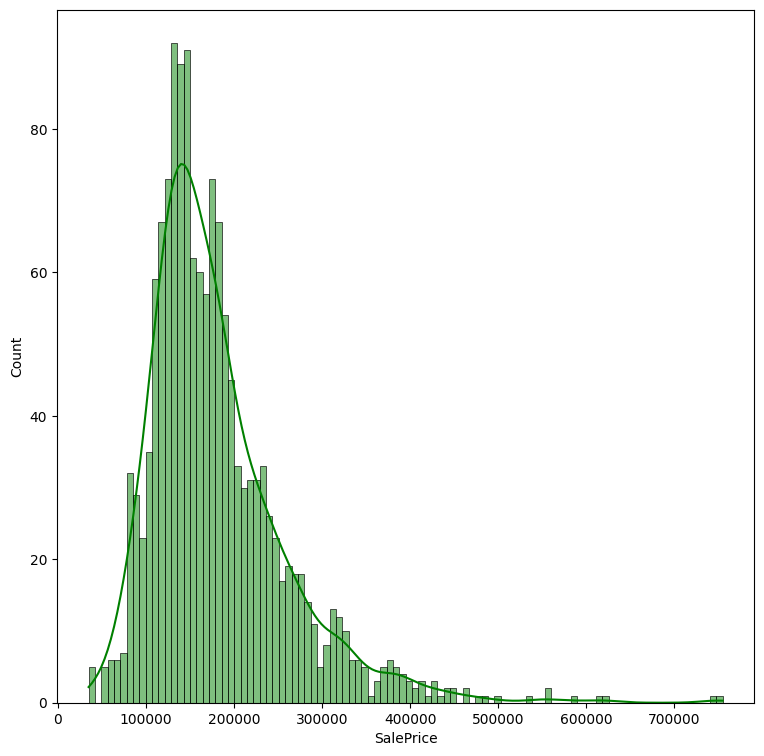

In [30]:
# SalePrice distribution
print(dataset_df['SalePrice'].describe())
plt.figure(figsize=(9, 9))
sns.histplot(dataset_df['SalePrice'], color='g', bins=100, kde=True)
plt.show()

array([[<Axes: title={'center': 'MSSubClass'}>,
        <Axes: title={'center': 'LotFrontage'}>,
        <Axes: title={'center': 'LotArea'}>,
        <Axes: title={'center': 'OverallQual'}>,
        <Axes: title={'center': 'OverallCond'}>,
        <Axes: title={'center': 'YearBuilt'}>,
        <Axes: title={'center': 'YearRemodAdd'}>],
       [<Axes: title={'center': 'MasVnrArea'}>,
        <Axes: title={'center': 'BsmtFinSF1'}>,
        <Axes: title={'center': 'BsmtFinSF2'}>,
        <Axes: title={'center': 'BsmtUnfSF'}>,
        <Axes: title={'center': 'TotalBsmtSF'}>,
        <Axes: title={'center': '1stFlrSF'}>,
        <Axes: title={'center': '2ndFlrSF'}>],
       [<Axes: title={'center': 'LowQualFinSF'}>,
        <Axes: title={'center': 'GrLivArea'}>,
        <Axes: title={'center': 'BsmtFullBath'}>,
        <Axes: title={'center': 'BsmtHalfBath'}>,
        <Axes: title={'center': 'FullBath'}>,
        <Axes: title={'center': 'HalfBath'}>,
        <Axes: title={'center': 'Bedroom

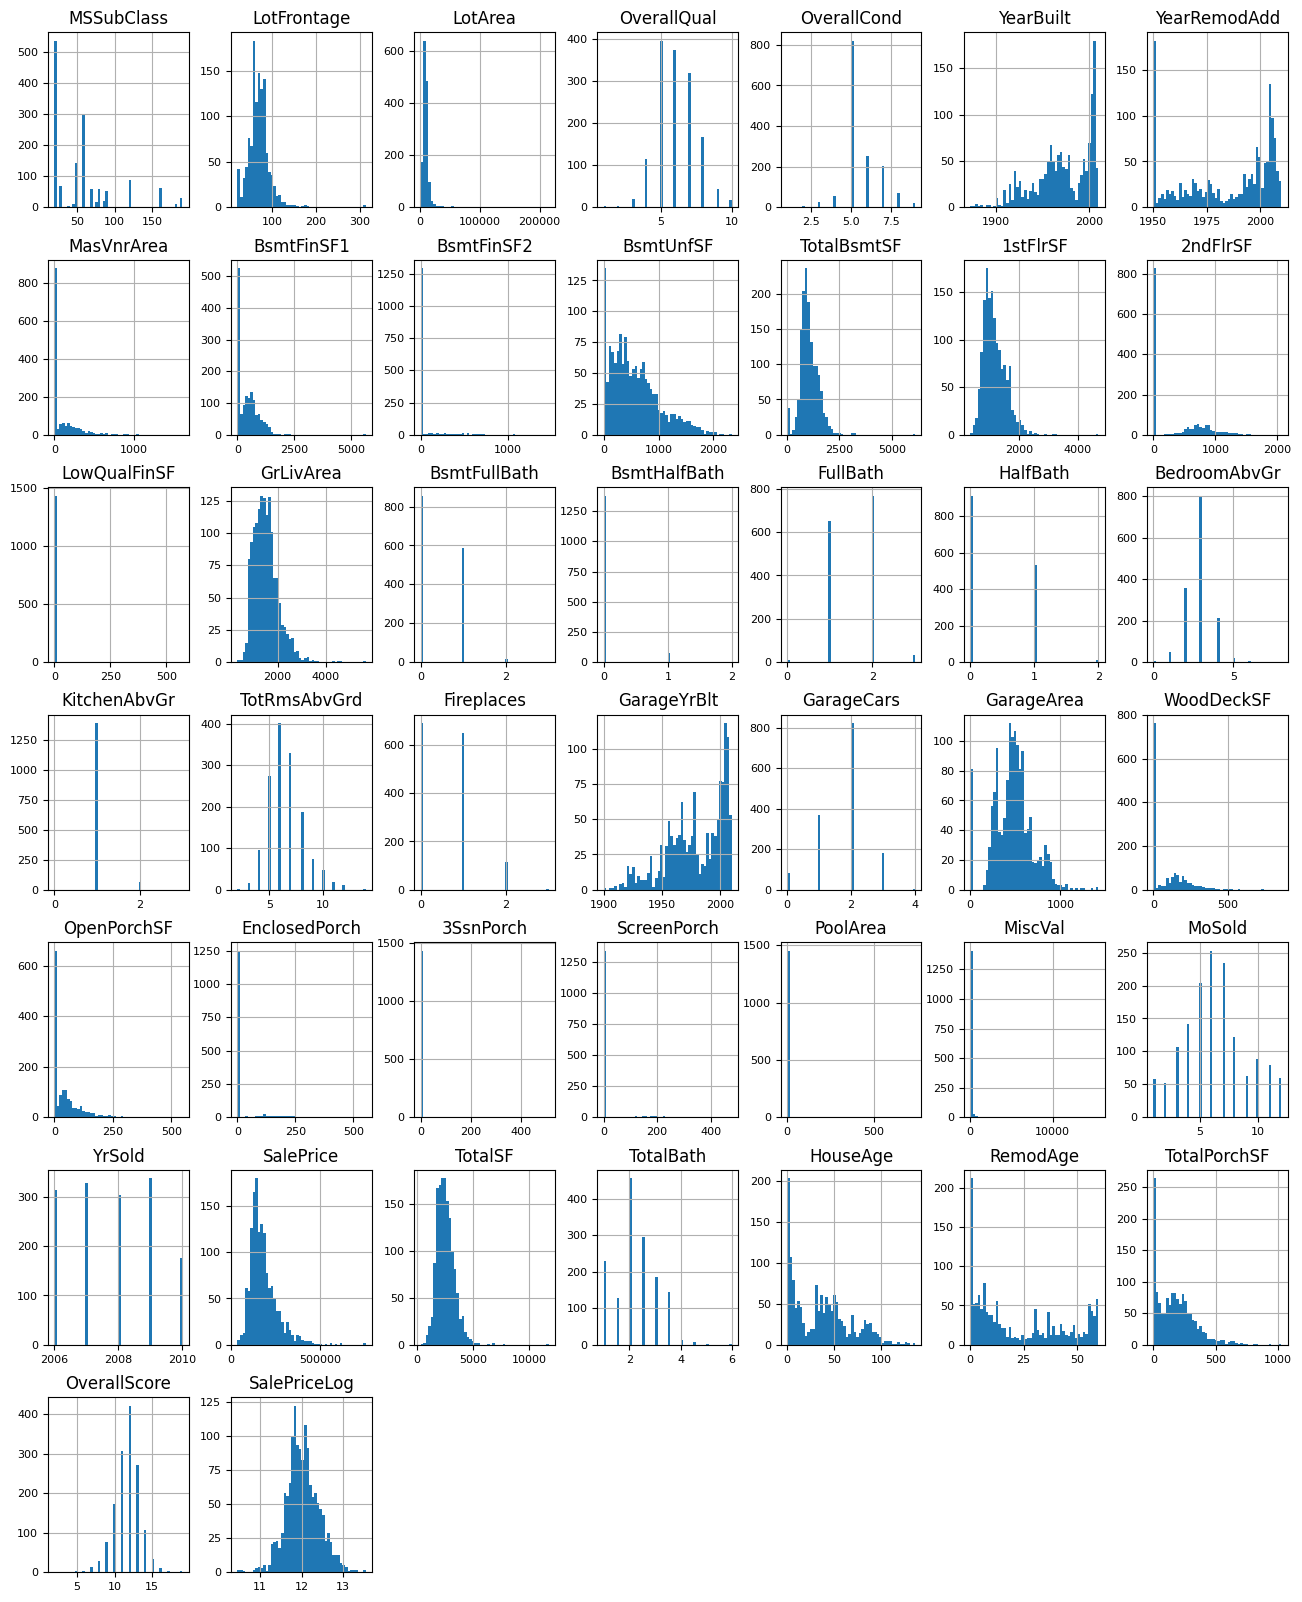

In [31]:
# Numerical features overview
list(set(dataset_df.dtypes.tolist()))
df_num = dataset_df.select_dtypes(include=['float64', 'int64'])
df_num.head(3)
df_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

In [32]:
# Train/validation split
import numpy as np
from sklearn.model_selection import train_test_split

train_ds_pd, valid_ds_pd = train_test_split(
    dataset_df,
    test_size=0.30,
    random_state=42,
    shuffle=True
 )

print(f"{len(train_ds_pd)} examples in training, {len(valid_ds_pd)} examples in testing.")

1022 examples in training, 438 examples in testing.


In [33]:
file_id2 = "1sJtMSOIRoFEWES6Iub7F_xSGq4OBkhT7"
url = f"https://drive.google.com/uc?id={file_id2}"

gdown.download(url, "test.csv", quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1sJtMSOIRoFEWES6Iub7F_xSGq4OBkhT7
To: /content/test.csv
100%|██████████| 451k/451k [00:00<00:00, 107MB/s]
100%|██████████| 451k/451k [00:00<00:00, 107MB/s]


'test.csv'

In [34]:
# Prepare Kaggle test set features
test_data = pd.read_csv("test.csv")
test_data = add_basic_features(test_data)
ids = test_data.get('Id', pd.Series(range(len(test_data)))).copy()
test_features = test_data[FEATURE_COLUMNS].copy()
test_data.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,MoSold,YrSold,SaleType,SaleCondition,TotalSF,TotalBath,HouseAge,RemodAge,TotalPorchSF,OverallScore
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,6,2010,WD,Normal,1778.0,1.0,49,49,260,11
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,6,2010,WD,Normal,2658.0,1.5,52,52,429,12
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,3,2010,WD,Normal,2557.0,2.5,13,12,246,10


In [36]:
# Train LightGBM regressor with engineered features
from sklearn.metrics import mean_absolute_error, mean_squared_log_error

X_train_lgb = train_ds_pd[FEATURE_COLUMNS]
y_train_lgb = train_ds_pd['SalePrice']
X_valid_lgb = valid_ds_pd[FEATURE_COLUMNS]
y_valid_lgb = valid_ds_pd['SalePrice']

lgbm_reg = lgb.LGBMRegressor(
    n_estimators=1500,
    learning_rate=0.03,
    num_leaves=64,
    feature_fraction=0.8,
    bagging_fraction=0.8,
    bagging_freq=5,
    reg_alpha=0.1,
    reg_lambda=0.2,
    random_state=42
)

lgbm_reg.fit(
    X_train_lgb,
    y_train_lgb,
    eval_set=[(X_valid_lgb, y_valid_lgb)],
    eval_metric='l1'
 )

valid_pred_lgb = lgbm_reg.predict(X_valid_lgb)
mae_lgb = mean_absolute_error(y_valid_lgb, valid_pred_lgb)
rmsle_lgb = mean_squared_log_error(y_valid_lgb, np.clip(valid_pred_lgb, 1, None)) ** 0.5
print(f"LightGBM MAE: {mae_lgb:,.2f}")
print(f"LightGBM RMSLE: {rmsle_lgb:.4f}")

[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1478
[LightGBM] [Info] Number of data points in

In [37]:
# Generate LightGBM predictions for submission
test_features_lgb = test_features[FEATURE_COLUMNS]
lightgbm_predictions = lgbm_reg.predict(test_features_lgb)
submission_lgb = pd.DataFrame({'Id': ids, 'SalePrice': lightgbm_predictions})
submission_lgb.to_csv('submission_lightgbm.csv', index=False)
submission_lgb.head()

[LightGBM] [Warning] feature_fraction is set=0.8, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.8
[LightGBM] [Warning] bagging_freq is set=5, subsample_freq=0 will be ignored. Current value: bagging_freq=5
[LightGBM] [Warning] bagging_fraction is set=0.8, subsample=1.0 will be ignored. Current value: bagging_fraction=0.8


,Id,SalePrice
0,1461,135166.127633
1,1462,171894.338982
2,1463,179241.665764
3,1464,191392.711844
4,1465,187990.083711


In [38]:
# Persist LightGBM model for reuse
import joblib
joblib.dump(lgbm_reg, "lightgbm_model.pkl")

['lightgbm_model.pkl']

In [39]:
# Preview LightGBM submission
submission_lgb.head()

,Id,SalePrice
0,1461,135166.127633
1,1462,171894.338982
2,1463,179241.665764
3,1464,191392.711844
4,1465,187990.083711


In [43]:
# Notebook-friendly prediction form
import ipywidgets as widgets
from IPython.display import display, clear_output

INT_FEATURES = {
    "OverallQual","OverallCond","GarageCars","FullBath","HalfBath",
    "BsmtFullBath","BsmtHalfBath","YearBuilt","YearRemodAdd","YrSold"
}

input_widgets = {}
for feature in RAW_FEATURE_INPUTS:
    default_val = STREAMLIT_DEFAULTS.get(feature, 0.0)
    if feature in INT_FEATURES:
        input_widgets[feature] = widgets.IntText(value=int(default_val), description=feature, layout=widgets.Layout(width='50%'))
    else:
        input_widgets[feature] = widgets.FloatText(value=float(default_val), description=feature, layout=widgets.Layout(width='50%'))

predict_button = widgets.Button(description="Predict Sale Price", button_style='success')
output = widgets.Output()

def _predict_callback(_):
    with output:
        clear_output()
        user_inputs = {f: widget.value for f, widget in input_widgets.items()}
        input_df = pd.DataFrame([user_inputs])
        feature_matrix = add_basic_features(input_df)[FEATURE_COLUMNS]
        prediction = float(lgbm_reg.predict(feature_matrix)[0])
        display(f"Estimated Sale Price: ${prediction:,.0f}")

predict_button.on_click(_predict_callback)

ui = widgets.VBox(list(input_widgets.values()) + [predict_button, output])
display(ui)